<a href="https://colab.research.google.com/github/Nurdaylight/An-Econ-771/blob/main/Experiments/Error_orthogonality_expeeriment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(42)

# Generate 100 observations
n = 3
X = np.random.rand(n) * 10  # Independent variable
# True relationship: y = 2.5 * X + 5 + noise
y = 2.5 * X + 5 + np.random.normal(0, 2, n)  # Dependent variable with noise

# Create a DataFrame
df = pd.DataFrame({'X': X, 'y': y})
display(df.head())

,X,y
0,3.745401,12.139743
1,9.507143,29.405662
2,7.319939,23.857931


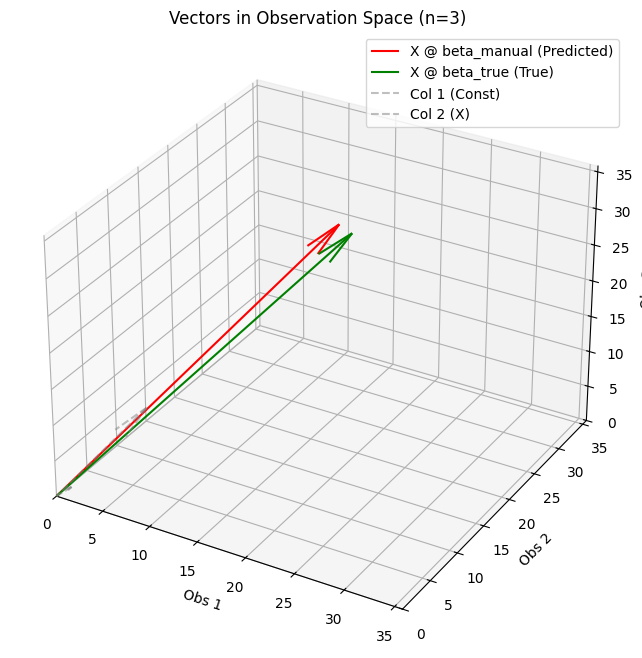

In [29]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define True Beta (Intercept=5, Slope=2.5)
beta_true = np.array([5, 2.5])

# Calculate vectors
# y_pred was calculated in the previous cell (X @ beta_manual)
# Calculate X @ beta_true
y_true_vec = X_const @ beta_true

# Convert to numpy arrays for plotting
v_manual = y_pred.values.flatten()
v_true = y_true_vec.values.flatten()

# Plotting
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Origin
origin = np.zeros(3)

# Plot X@beta_manual
ax.quiver(0, 0, 0, v_manual[0], v_manual[1], v_manual[2], color='red', label='X @ beta_manual', arrow_length_ratio=0.1, linewidth=2)

# Plot X@beta_true
ax.quiver(0, 0, 0, v_true[0], v_true[1], v_true[2], color='green', label='X @ beta_true', arrow_length_ratio=0.1, linewidth=2)

# Plot the columns of X to show the Column Space basis
col1 = X_const['const'].values
col2 = X_const['X'].values
ax.quiver(0, 0, 0, col1[0], col1[1], col1[2], color='gray', linestyle='--', alpha=0.5, label='Basis Vector 1 (Const)')
ax.quiver(0, 0, 0, col2[0], col2[1], col2[2], color='gray', linestyle='--', alpha=0.5, label='Basis Vector 2 (X)')

# --- Visualize the 2D Column Space (Plane) ---
# Create a meshgrid of coefficients (betas) to define the plane
b0_range = np.linspace(0, 6, 10)
b1_range = np.linspace(0, 4, 10)
B0, B1 = np.meshgrid(b0_range, b1_range)

# Calculate the corresponding coordinates in Observation Space (3D)
# Z_plane = B0 * col1 + B1 * col2
Plane_X = B0 * col1[0] + B1 * col2[0]
Plane_Y = B0 * col1[1] + B1 * col2[1]
Plane_Z = B0 * col1[2] + B1 * col2[2]

# Plot the surface
surf = ax.plot_surface(Plane_X, Plane_Y, Plane_Z, alpha=0.2, color='cyan')
# Add a proxy artist for the legend
import matplotlib.patches as mpatches
plane_proxy = mpatches.Patch(color='cyan', alpha=0.2, label='Column Space (2D Plane)')

# Set limits
limit = max(np.max(np.abs(v_manual)), np.max(np.abs(v_true))) * 1.2
ax.set_xlim([0, limit])
ax.set_ylim([0, limit])
ax.set_zlim([0, limit])

ax.set_xlabel('Obs 1')
ax.set_ylabel('Obs 2')
ax.set_zlabel('Obs 3')
ax.set_title('OLS Geometry: Vectors on the Column Space Plane')

# Custom legend handling
handles, labels = ax.get_legend_handles_labels()
handles.append(plane_proxy)
ax.legend(handles=handles)

plt.show()

In [27]:
# Define predictors (add constant for intercept)
X_const = sm.add_constant(df['X'])

# Manual OLS regression: (X^T * X)^(-1) * X^T * y
# Calculating beta using the normal equation
beta_manual = np.linalg.inv(X_const.T @ X_const) @ X_const.T @ df['y']

print("Manual Coefficients:")
print(beta_manual)
print("-" * 30)



Manual Coefficients:
0    1.06295
1    3.02416
dtype: float64
------------------------------


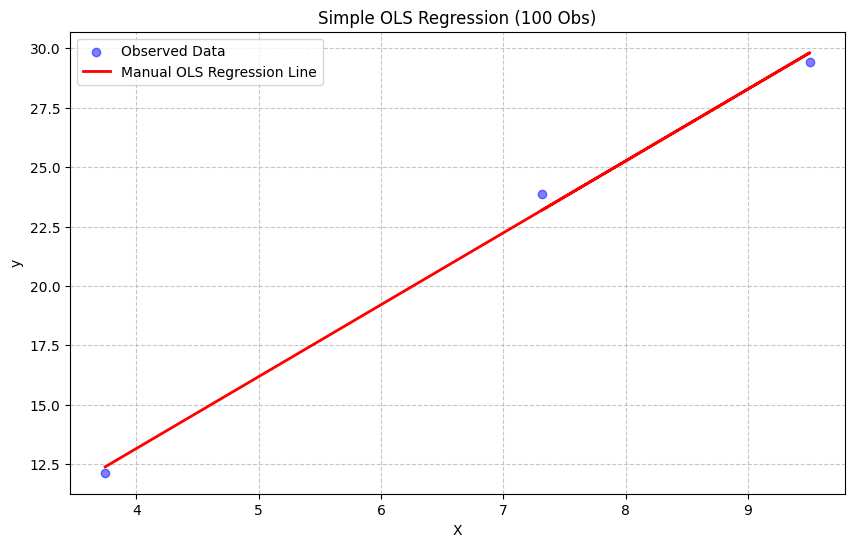

In [28]:
# Calculate predictions using manual beta
y_pred = X_const @ beta_manual.values.reshape(2, -1)
# Plot the data and the regression line
plt.figure(figsize=(10, 6))
plt.scatter(df['X'], df['y'], color='blue', alpha=0.5, label='Observed Data')
plt.plot(df['X'], y_pred, color='red', linewidth=2, label='Manual OLS Regression Line')

plt.title('Simple OLS Regression (100 Obs)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

(2,)

array([[5.43019232],
       [2.40804535]])